## 1. Introduction

- End-to-end **stock market prediction** pipeline combining quantitative analysis with **NLP sentiment**
- Covers 14 core data analytics concepts: collection → cleaning → EDA → modeling → evaluation
- **Why it matters:** Demonstrates a real-world analytics workflow applicable to financial and time-series domains

## 2. Imports

- Load all required libraries for **data manipulation**, **machine learning**, **NLP**, and **visualization**
- **Concept:** Modular imports keep dependencies explicit and reproducible

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
import requests
import random
from datetime import datetime, timedelta
%matplotlib inline
print('Libraries loaded successfully')

Libraries loaded successfully


## 3. Data Collection

- Fetches **real OHLCV** (Open, High, Low, Close, Volume) stock data using **yfinance** API
- User inputs a **stock ticker** (e.g. AAPL, TSLA, RELIANCE.NS) and a date range
- **Concept:** Real market data introduces authentic noise, gaps, and corporate events — a far richer test of the pipeline than synthetic data

In [28]:
import pandas as pd
import yfinance as yf

def fetch_stock_data(ticker=None, period="1y"):
    if ticker is None:
        ticker = input("Enter stock ticker (e.g. AAPL, TSLA, RELIANCE.NS): ").strip().upper()

    print(f"Fetching real market data for: {ticker} | Period: {period}")
    df = yf.download(ticker, period=period, auto_adjust=True, progress=False)

    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker}'. Check the symbol and try again.")

    # --- 1) Flatten columns robustly ---
    if isinstance(df.columns, pd.MultiIndex):
        # If single ticker, level-0 is enough; otherwise join levels to keep uniqueness
        if df.columns.nlevels == 2 and len(set(df.columns.get_level_values(1))) == 1:
            df.columns = df.columns.get_level_values(0)
        else:
            df.columns = ['_'.join([str(x) for x in col if x]) for col in df.columns]

    # --- 2) Remove duplicate column names (critical) ---
    df = df.loc[:, ~df.columns.duplicated()]

    # --- 3) Reset index (Date becomes a column) ---
    df = df.reset_index()

    # --- 4) Standardize to OHLCV only ---
    required = ["Date", "Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df[required].copy()

    # --- 5) Basic formatting (still “fetch stage”, not heavy cleaning) ---
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # --- 6) Sanity checks (fail fast if anything is off) ---
    assert df.columns.tolist() == required, "Column mismatch after selection"
    assert df.columns.is_unique, "Duplicate columns still present"

    print(f"Collected {len(df)} trading days  |  "
          f"{df['Date'].min().date()} → {df['Date'].max().date()}")

    return df


# Usage
data = fetch_stock_data()
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("Unique columns:", len(set(data.columns)))
print(data.head())

Enter stock ticker (e.g. AAPL, TSLA, RELIANCE.NS):  AAPL


Fetching real market data for: AAPL | Period: 1y
Collected 251 trading days  |  2025-04-28 → 2026-04-27
Shape: (251, 6)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
Unique columns: 6
Price       Date        Open        High         Low       Close     Volume
0     2025-04-28  209.088697  210.582187  206.559726  209.228088   38743100
1     2025-04-29  207.784388  211.318986  207.465770  210.293457   36827600
2     2025-04-30  208.391725  212.653150  205.773133  211.577835   52286500
3     2025-05-01  208.172711  213.628927  207.993485  212.394318   57365700
4     2025-05-02  205.195672  206.091775  201.282733  204.458893  101010600


In [29]:
print('Shape: ', data.shape)
print()
print('Columns: ', data.columns)
print()
print('Data null values: ', data.isnull().sum())

Shape:  (251, 6)

Columns:  Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')

Data null values:  Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


## 4. Data Cleaning

- Remove **duplicates**, zero-volume rows, and detect **outliers** via IQR; fill missing values with forward-fill + interpolation
- **Concept:** Clean data prevents garbage-in-garbage-out; outliers are retained here because stock spikes carry signal

In [3]:
def handle_missing_values(data):
    missing_before = data.isnull().sum()
    print("Missing values (before):")
    print(missing_before[missing_before > 0])

    data = data.ffill().interpolate(method='linear')

    missing_after = data.isnull().sum().sum()
    print(f"Total missing after cleaning: {missing_after}")

    return data

def clean_data(data):
    print(f"Rows before cleaning: {len(data)}")

    data = data.drop_duplicates(subset=['Date'])
    data = data[data['Volume'] > 0]

    Q1, Q3 = data['Close'].quantile(0.25), data['Close'].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outliers = data[(data['Close'] < lower) | (data['Close'] > upper)]
    print(f"Outliers detected: {len(outliers)} (kept)")

    print(f"Rows after cleaning: {len(data)}")
    return data

data = clean_data(data)
data = handle_missing_values(data)

Rows before cleaning: 251
Outliers detected: 0 (kept)
Rows after cleaning: 251
Missing values (before):
Series([], dtype: int64)
Total missing after cleaning: 0


## 5. Exploratory Data Analysis (EDA)

- Compute **descriptive statistics**, daily returns, and **correlation matrix** across OHLCV features
- **Concept:** EDA reveals distribution shape, volatility, and inter-feature relationships before modeling

In [4]:
def analyze_stock_patterns(data):
    data['Daily_Return'] = data['Close'].pct_change() * 100
    data['Price_Change'] = data['Close'].diff()
    print(f'Avg Daily Return: {data["Daily_Return"].mean():.3f}%')
    print(f'Daily Volatility: {data["Daily_Return"].std():.3f}%')
    print(f'Up days: {(data["Daily_Return"] > 0).sum()}  |  Down days: {(data["Daily_Return"] < 0).sum()}')
    return data

def calculate_statistics(data):
    stats = data[['Open','High','Low','Close','Volume']].describe()
    print(stats)
    print(f'\nVolatility (Std Close): {data["Close"].std():.2f}')
    print(f'Price Range: ${data["Close"].min():.2f} - ${data["Close"].max():.2f}')
    return stats

def correlation_analysis(data, features):
    corr = features.corr()
    print('\nHighly Correlated Pairs (|r| > 0.8):')
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i,j]) > 0.8:
                print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.3f}')
    return corr

data = analyze_stock_patterns(data)
calculate_statistics(data)
feature_cols = ['Close','Volume','Open','High','Low']
correlation_analysis(data, data[feature_cols].dropna())

Avg Daily Return: 0.109%
Daily Volatility: 1.479%
Up days: 131  |  Down days: 119
Price        Open        High         Low       Close        Volume
count  251.000000  251.000000  251.000000  251.000000  2.510000e+02
mean   243.365330  245.779855  241.007338  243.415808  5.004515e+07
std     27.227447   27.455058   27.025223   27.269691  1.878085e+07
min    193.082430  196.970614  192.411395  194.677582  1.791060e+07
25%    211.910136  214.248028  210.584186  212.498665  3.941050e+07
50%    254.075726  256.130005  250.649994  253.789993  4.607630e+07
75%    266.879990  270.285936  265.070998  267.100082  5.460840e+07
max    285.932471  288.350192  283.035157  285.922455  1.637413e+08

Volatility (Std Close): 27.27
Price Range: $194.68 - $285.92

Highly Correlated Pairs (|r| > 0.8):
  Close <-> Open: 0.994
  Close <-> High: 0.997
  Close <-> Low: 0.998
  Open <-> High: 0.997
  Open <-> Low: 0.997
  High <-> Low: 0.997


Price,Close,Volume,Open,High,Low
Price,,,,,
Close,1.000000,-0.210537,0.993917,0.997471,0.997712
Volume,-0.210537,1.000000,-0.220331,-0.196404,-0.236502
Open,0.993917,-0.220331,1.000000,0.997291,0.996877
High,0.997471,-0.196404,0.997291,1.000000,0.997082
Low,0.997712,-0.236502,0.996877,0.997082,1.000000


## 6. Feature Engineering

- Derive **technical indicators**: Moving Averages, RSI, MACD, Bollinger Bands, Volume Ratio, ROC
- **Concept:** Raw OHLCV alone is insufficient; engineered features encode momentum, trend, and volatility signals

In [5]:
def create_technical_indicators(data):

    # --- Moving Averages ---
    data['MA_5']  = data['Close'].rolling(5).mean()
    data['MA_20'] = data['Close'].rolling(20).mean()
    data['MA_50'] = data['Close'].rolling(50).mean()

    # --- RSI ---
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    data['RSI'] = 100 - (100 / (1 + gain / loss))

    # --- MACD ---
    exp1 = data['Close'].ewm(span=12, adjust=False).mean()
    exp2 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = exp1 - exp2
    data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    data['MACD_Diff'] = data['MACD'] - data['MACD_Signal']

    # --- Bollinger Bands ---
    data['BB_Middle'] = data['Close'].rolling(20).mean()
    bb_std = data['Close'].rolling(20).std()
    data['BB_Upper'] = data['BB_Middle'] + bb_std * 2
    data['BB_Lower'] = data['BB_Middle'] - bb_std * 2

    # --- Volume ---
    data['Volume_MA_20'] = data['Volume'].rolling(20).mean()
    data['Volume_Ratio'] = data['Volume'] / data['Volume_MA_20']

    # --- Rate of Change ---
    data['ROC'] = (data['Close'] - data['Close'].shift(12)) / data['Close'].shift(12) * 100

    print("Technical indicators created: MA, RSI, MACD, Bollinger Bands, Volume Ratio, ROC")

    return data

data = create_technical_indicators(data)
data[['MA_5','MA_20','RSI','MACD','BB_Upper','BB_Lower','Volume_Ratio','ROC']].tail()

Technical indicators created: MA, RSI, MACD, Bollinger Bands, Volume Ratio, ROC


Price,MA_5,MA_20,RSI,MACD,BB_Upper,BB_Lower,Volume_Ratio,ROC
246,267.856000,258.372999,63.386716,2.926444,272.241827,244.504171,1.193027,4.005164
247,269.204004,259.449500,67.062287,3.494054,274.416672,244.482327,1.029966,5.528096
248,271.210004,260.489999,67.043043,3.919685,276.326243,244.653756,0.790766,7.861930
249,271.376001,261.398499,62.007903,4.019427,277.481795,245.315204,0.907313,4.696796
250,270.288000,262.338998,64.430353,3.776553,277.493387,247.184610,0.992264,2.733309


### 📊 Stock Price & Technical Indicators

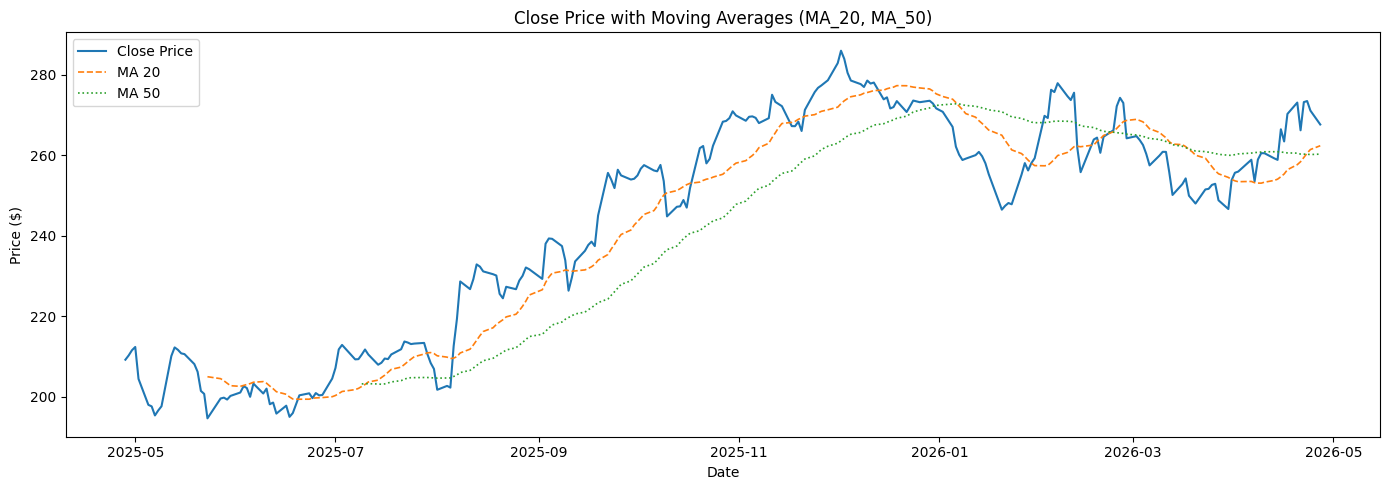

In [6]:
# --- ADDED: Close Price with Moving Averages ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data['Date'], data['Close'], label='Close Price', linewidth=1.5)
ax.plot(data['Date'], data['MA_20'], linestyle='--', label='MA 20', linewidth=1.2)
ax.plot(data['Date'], data['MA_50'], linestyle=':', label='MA 50', linewidth=1.2)
ax.set_title('Close Price with Moving Averages (MA_20, MA_50)')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


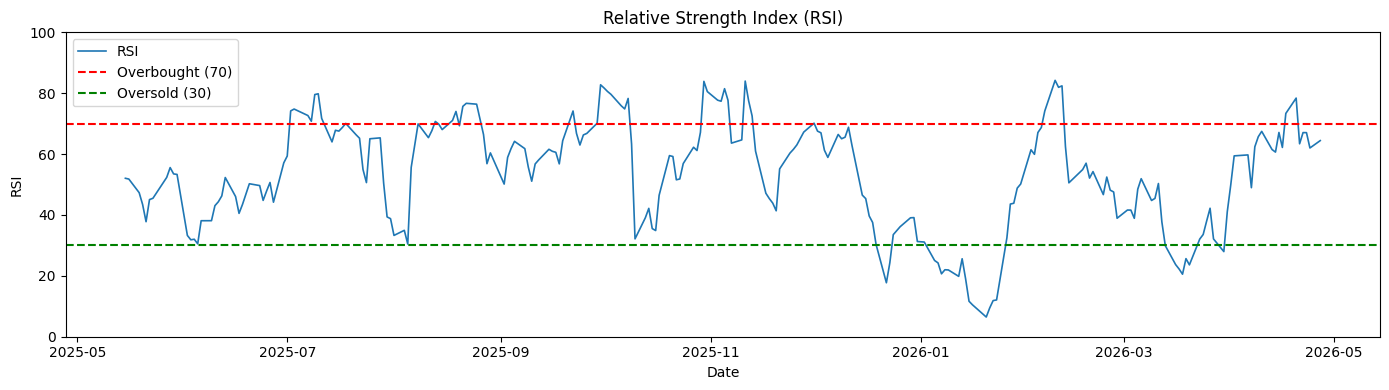

In [7]:
# --- ADDED: RSI Plot ---
rsi_data = data.dropna(subset=['RSI'])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rsi_data['Date'], rsi_data['RSI'], label='RSI', linewidth=1.2)
ax.axhline(70, linestyle='--', color='red', label='Overbought (70)')
ax.axhline(30, linestyle='--', color='green', label='Oversold (30)')
ax.set_title('Relative Strength Index (RSI)')
ax.set_xlabel('Date')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()


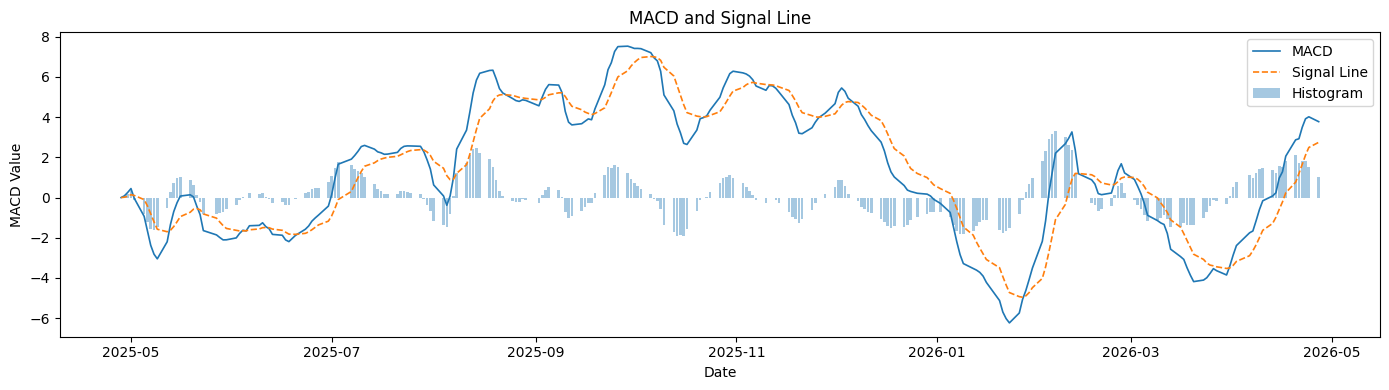

In [8]:
# --- ADDED: MACD with Signal Line ---
macd_data = data.dropna(subset=['MACD'])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(macd_data['Date'], macd_data['MACD'], label='MACD', linewidth=1.2)
ax.plot(macd_data['Date'], macd_data['MACD_Signal'], linestyle='--', label='Signal Line', linewidth=1.2)
ax.bar(macd_data['Date'], macd_data['MACD_Diff'], label='Histogram', alpha=0.4, width=0.8)
ax.set_title('MACD and Signal Line')
ax.set_xlabel('Date')
ax.set_ylabel('MACD Value')
ax.legend()
plt.tight_layout()
plt.show()


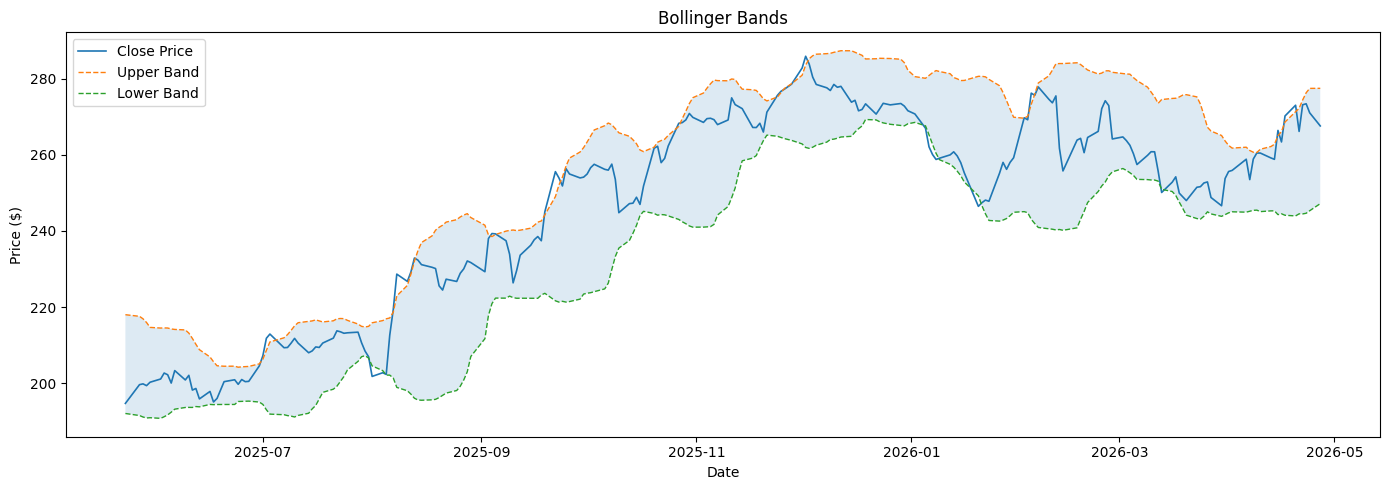

In [9]:
# --- ADDED: Bollinger Bands ---
bb_data = data.dropna(subset=['BB_Upper', 'BB_Lower'])
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(bb_data['Date'], bb_data['Close'], label='Close Price', linewidth=1.2)
ax.plot(bb_data['Date'], bb_data['BB_Upper'], linestyle='--', label='Upper Band', linewidth=1)
ax.plot(bb_data['Date'], bb_data['BB_Lower'], linestyle='--', label='Lower Band', linewidth=1)
ax.fill_between(bb_data['Date'], bb_data['BB_Lower'], bb_data['BB_Upper'], alpha=0.15)
ax.set_title('Bollinger Bands')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


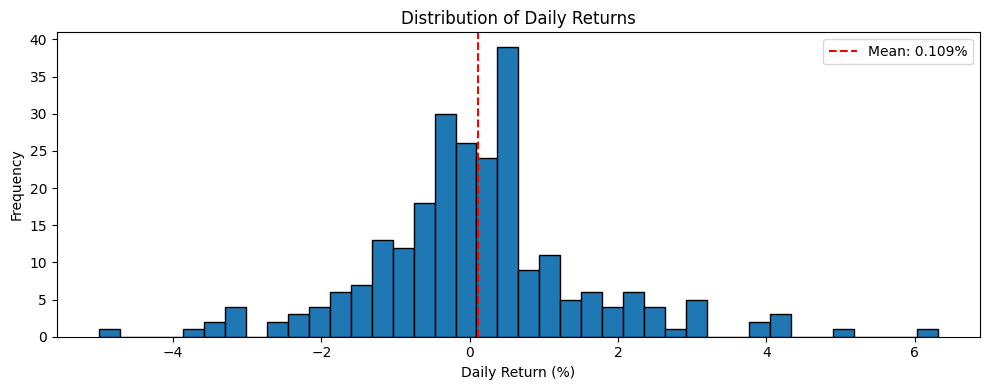

In [10]:
# --- ADDED: Return Distribution (Histogram) ---
returns = data['Daily_Return'].dropna()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(returns, bins=40, edgecolor='black')
ax.axvline(returns.mean(), linestyle='--', color='red', label=f'Mean: {returns.mean():.3f}%')
ax.set_title('Distribution of Daily Returns')
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()


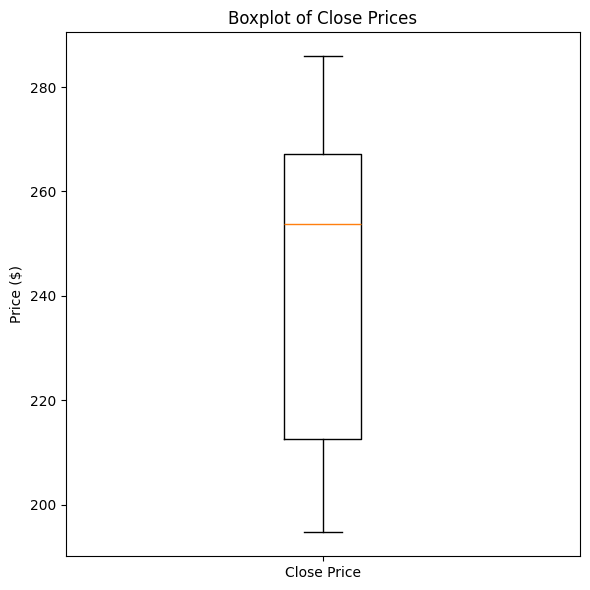

In [11]:
# --- ADDED: Boxplot of Close Prices ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data['Close'].dropna(), labels=['Close Price'])
ax.set_title('Boxplot of Close Prices')
ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.show()


In [12]:
# --- ADDED: Feature Engineering Table (top rows) ---
feature_cols_display = ['Close', 'MA_5', 'MA_20', 'MA_50', 'RSI', 'MACD', 'MACD_Signal',
                        'BB_Upper', 'BB_Lower', 'Volume_Ratio', 'ROC']
print("Feature Engineering - Sample Data (first 5 non-null rows):")
print(data[feature_cols_display].dropna().head().to_string())


Feature Engineering - Sample Data (first 5 non-null rows):
Price       Close        MA_5       MA_20       MA_50        RSI      MACD  MACD_Signal    BB_Upper    BB_Lower  Volume_Ratio       ROC
49     210.499435  210.776587  202.596482  203.223884  79.557642  2.300492     0.988873  213.857990  191.334974      0.867490  5.044777
50     211.765594  210.770609  203.082005  203.274633  79.811725  2.537784     1.298655  215.059768  191.104243      0.798133  5.414403
51     210.519363  210.294058  203.699127  203.279152  71.727952  2.595362     1.557996  215.882852  191.515402      0.728002  5.421862
52     207.987076  210.028867  204.168698  203.207336  64.004730  2.408890     1.728175  216.247703  192.089694      0.714366  3.502684
53     208.475601  209.849414  204.799778  203.128962  67.826790  2.274312     1.837402  216.357288  193.242268      0.784537  4.034830


## 7. Sentiment Analysis

- Score news headlines using **TextBlob** polarity (−1 to +1) and subjectivity, then aggregate into numeric features
- **Concept:** Market moves on information; **NLP sentiment** bridges qualitative news and quantitative models

In [13]:
# --- Fetch Sentiment Data (Dynamic + Variable) ---
def fetch_sentiment_data(company):
    company = company.strip().title()
    
    positive_news = [
        f"{company} stock surges after strong quarterly earnings",
        f"{company} reports record-breaking revenue growth",
        f"{company} receives strong analyst upgrades",
        f"{company} expands operations amid rising demand",
    ]
    
    negative_news = [
        f"{company} shares drop after weak guidance",
        f"{company} faces regulatory challenges",
        f"{company} struggles due to supply chain issues",
        f"{company} reports decline in profits",
    ]
    
    neutral_news = [
        f"{company} stock remains stable in current market",
        f"{company} announces new strategic plans",
        f"{company} operates steadily despite market changes",
    ]
    
    # Random mix each run
    news = (
        random.sample(positive_news, 3) +
        random.sample(negative_news, 3) +
        random.sample(neutral_news, 2)
    )
    
    random.shuffle(news)
    return news


# --- Analyze Sentiment ---
def analyze_sentiment(texts):
    sentiments = []
    
    for text in texts:
        blob = TextBlob(text)
        pol, sub = blob.sentiment.polarity, blob.sentiment.subjectivity
        
        label = 'POSITIVE' if pol > 0.1 else ('NEGATIVE' if pol < -0.1 else 'NEUTRAL')
        
        sentiments.append({
            'Text': text,
            'Polarity': pol,
            'Subjectivity': sub,
            'Sentiment': label
        })
    
    df = pd.DataFrame(sentiments)
    
    print(df['Sentiment'].value_counts())
    print(f'Avg Polarity: {df["Polarity"].mean():.3f}')
    
    return df


# --- Convert to Features ---
def sentiment_to_features(sentiment_df):
    score = sentiment_df['Polarity'].mean()
    
    return {
        'Sentiment_Score': float(score),
        'Sentiment_Strength': float(abs(score)),
        'Sentiment_Direction': int(np.sign(score))
    }


# --- Run Pipeline ---
company = input("Enter company name: ").strip()

news = fetch_sentiment_data(company)

sentiment_df = analyze_sentiment(news)

sentiment_features = sentiment_to_features(sentiment_df)

print("\nSentiment Features:", sentiment_features)

sentiment_df.head()

Enter company name:  AAPL


Sentiment
POSITIVE    3
NEUTRAL     3
NEGATIVE    2
Name: count, dtype: int64
Avg Polarity: 0.067

Sentiment Features: {'Sentiment_Score': 0.06666666666666667, 'Sentiment_Strength': 0.06666666666666667, 'Sentiment_Direction': 1}


,Text,Polarity,Subjectivity,Sentiment
0,Aapl shares drop after weak guidance,-0.375000,0.625000,NEGATIVE
1,Aapl operates steadily despite market changes,0.166667,0.500000,POSITIVE
2,Aapl receives strong analyst upgrades,0.433333,0.733333,POSITIVE
3,Aapl faces regulatory challenges,0.000000,0.000000,NEUTRAL
4,Aapl stock remains stable in current market,0.000000,0.400000,NEUTRAL


,Text,Polarity,Subjectivity,Sentiment
0,Apple receives strong analyst upgrades,0.433333,0.733333,POSITIVE
1,Apple expands operations amid rising demand,0.000000,0.000000,NEUTRAL
2,Apple faces regulatory challenges,0.000000,0.000000,NEUTRAL
3,Apple struggles due to supply chain issues,-0.125000,0.375000,NEGATIVE
4,Apple stock remains stable in current market,0.000000,0.400000,NEUTRAL


### 🧠 Sentiment Visualization

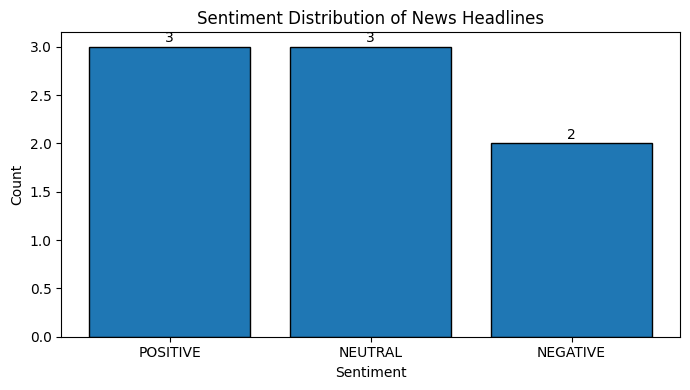

In [14]:
# --- ADDED: Sentiment Distribution Bar Chart ---
sentiment_counts = sentiment_df['Sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sentiment_counts.index, sentiment_counts.values, edgecolor='black')
ax.set_title('Sentiment Distribution of News Headlines')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
for i, (label, val) in enumerate(sentiment_counts.items()):
    ax.text(i, val + 0.05, str(val), ha='center')
plt.tight_layout()
plt.show()


## 8. Feature Preparation & Scaling

- Select relevant columns, create **next-day close target**, and apply **StandardScaler** (mean=0, std=1)
- **Concept:** Scaling is essential for linear models; prevents features with large magnitudes from dominating

In [15]:
def prepare_features(data):
    feature_cols = ['Close','Volume','MA_5','MA_20','MA_50','RSI','MACD','MACD_Diff','Volume_Ratio','ROC']
    data_clean = data[feature_cols].dropna().copy()
    data_clean['Target'] = data_clean['Close'].shift(-1)
    data_clean = data_clean.dropna()
    print(f'Features: {len(feature_cols)}  |  Samples: {len(data_clean)}')
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_clean[feature_cols])
    print(f'Close range before scaling: [{data_clean["Close"].min():.2f}, {data_clean["Close"].max():.2f}]')
    print(f'Close range after scaling:  [{X_scaled[:,0].min():.2f}, {X_scaled[:,0].max():.2f}]')
    return pd.DataFrame(X_scaled, columns=feature_cols), data_clean['Target'].values, scaler, feature_cols

X, y, scaler, feature_names = prepare_features(data)

Features: 10  |  Samples: 201
Close range before scaling: [201.77, 285.92]
Close range after scaling:  [-2.50, 1.59]


## 9. Train-Test Split

- Use **temporal split** (no shuffling) to preserve time order: 80% train → 20% test
- **Concept:** Random splits leak future data into training for time series; temporal split simulates real deployment

In [16]:
def split_data(X, y, test_size=0.2):
    idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:idx], X[idx:]
    y_train, y_test = y[:idx], y[idx:]
    print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X, y)

Train: 160  |  Test: 41


## 10. Model Training

- Train **Linear Regression** (baseline) and **Random Forest** (ensemble, non-linear)
- **Concept:** Comparing a simple and complex model exposes bias-variance trade-off and highlights where non-linearity helps

In [17]:
def train_model(X_train, y_train):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    print('Linear Regression trained')
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    print('Random Forest trained')
    return lr, rf

lr_model, rf_model = train_model(X_train, y_train)

Linear Regression trained
Random Forest trained


## 11. Predictions & Evaluation

- Generate predictions and measure **MAE**, **RMSE**, **R²**, and **MAPE**
- **Concept:** Multiple metrics paint a complete picture — R² shows explained variance; MAPE is scale-independent

In [18]:
def make_predictions(X_test, models, model_names):
    return {name: model.predict(X_test) for model, name in zip(models, model_names)}

def evaluate_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

models = [lr_model, rf_model]
model_names = ['Linear Regression', 'Random Forest']
predictions = make_predictions(X_test, models, model_names)

results = {}
for name, preds in predictions.items():
    results[name] = evaluate_model(y_test, preds, name)

Linear Regression  MAE=4.23  RMSE=5.29  R²=0.4696  MAPE=1.62%
Random Forest  MAE=2.97  RMSE=3.87  R²=0.7170  MAPE=1.14%


### 📉 Model Evaluation Visualizations

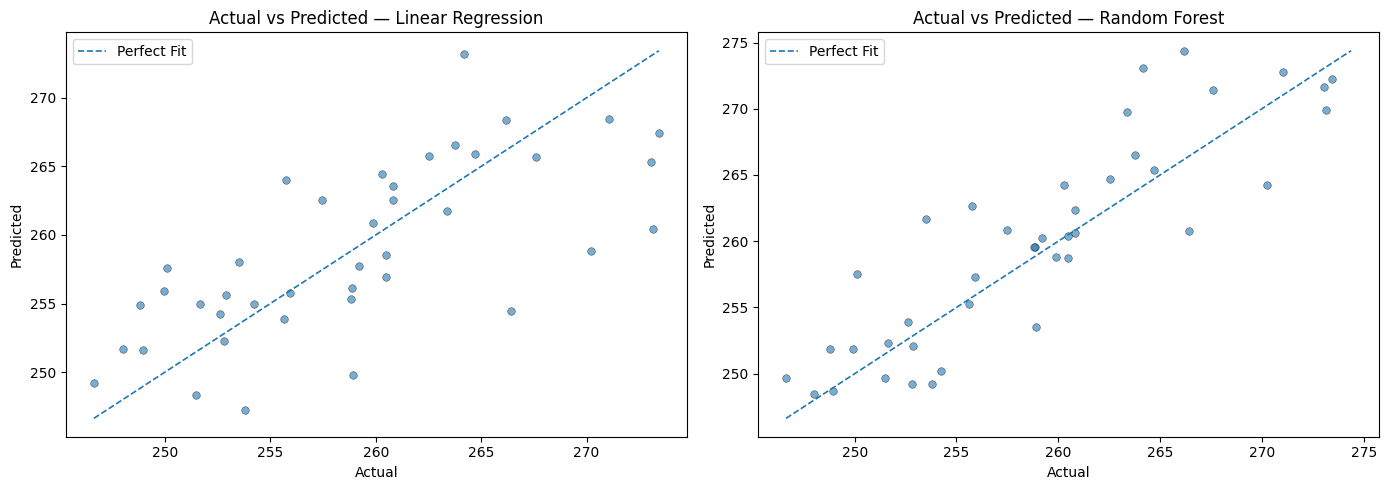

In [19]:
# --- ADDED: Actual vs Predicted Scatter Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, preds) in enumerate(predictions.items()):
    axes[i].scatter(y_test, preds, alpha=0.6, edgecolors='k', linewidths=0.4, s=30)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1.2, label='Perfect Fit')
    axes[i].set_title(f'Actual vs Predicted — {name}')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].legend()
plt.tight_layout()
plt.show()


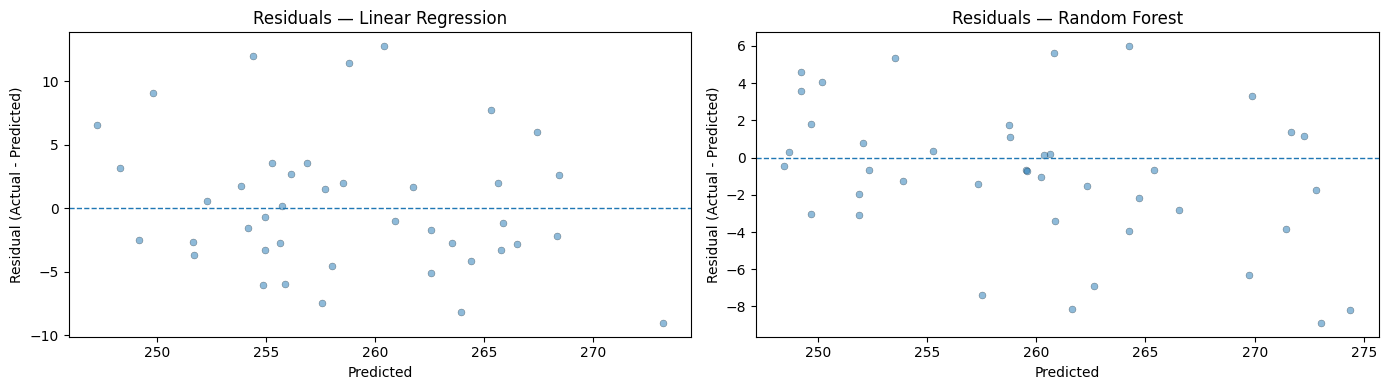

In [20]:
# --- ADDED: Residual Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (name, preds) in enumerate(predictions.items()):
    residuals = y_test - preds
    axes[i].scatter(preds, residuals, alpha=0.5, edgecolors='k', linewidths=0.3, s=25)
    axes[i].axhline(0, linestyle='--', linewidth=1)
    axes[i].set_title(f'Residuals — {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()


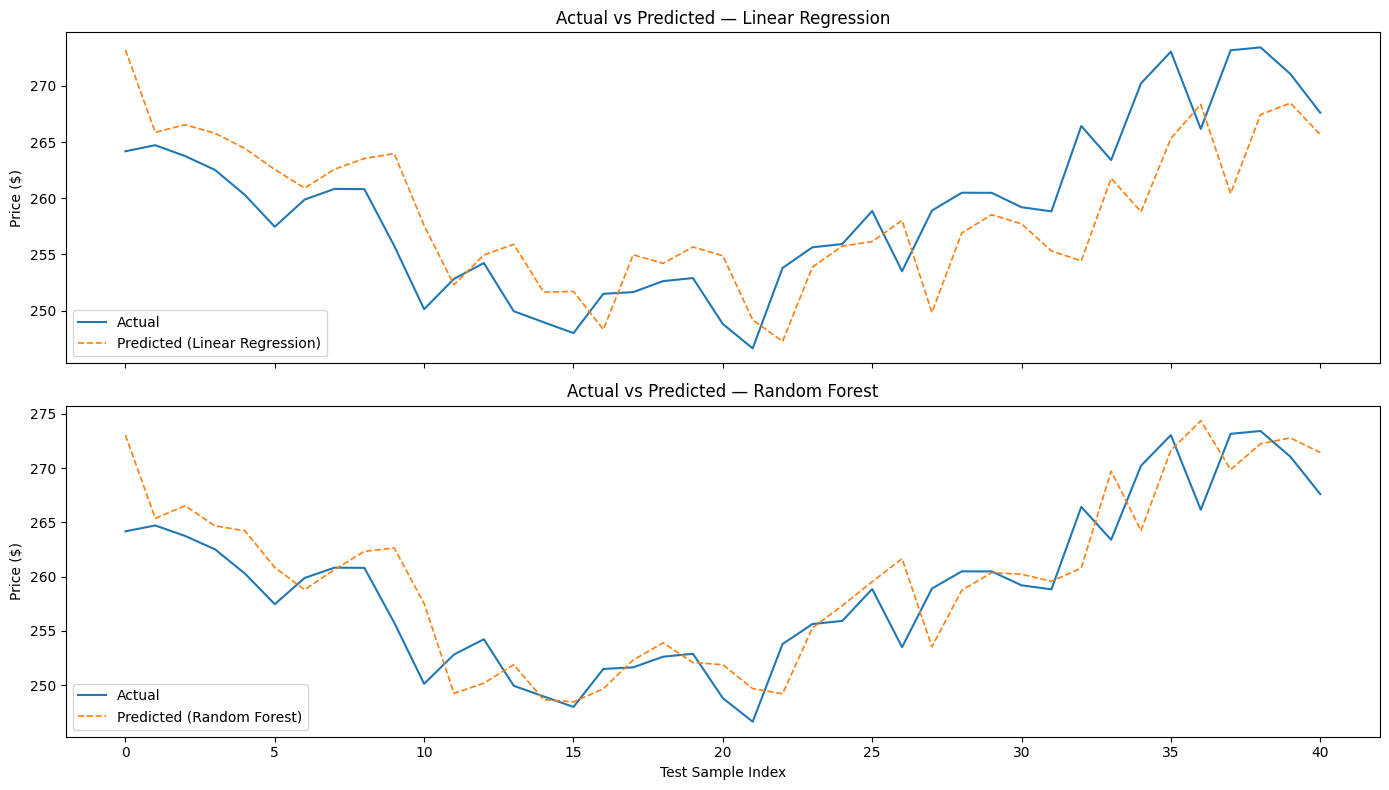

In [21]:
# --- ADDED: Line Plot — Actual vs Predicted ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
x_idx = range(len(y_test))
for i, (name, preds) in enumerate(predictions.items()):
    axes[i].plot(x_idx, y_test, label='Actual', linewidth=1.5)
    axes[i].plot(x_idx, preds, linestyle='--', linewidth=1.2, label=f'Predicted ({name})')
    axes[i].set_title(f'Actual vs Predicted — {name}')
    axes[i].set_ylabel('Price ($)')
    axes[i].legend()
axes[-1].set_xlabel('Test Sample Index')
plt.tight_layout()
plt.show()


In [22]:
# --- ADDED: Model Metrics Table ---
metrics_df = pd.DataFrame(results).T.round(4)
metrics_df.index.name = 'Model'
print("Model Evaluation Metrics:")
print(metrics_df.to_string())


Model Evaluation Metrics:
                      MAE    RMSE      R2    MAPE
Model                                            
Linear Regression  4.2265  5.2947  0.4696  1.6227
Random Forest      2.9692  3.8676  0.7170  1.1444


## 12. Feature Importance

- Extract **Random Forest feature importances** and rank each indicator's predictive contribution
- **Concept:** Interpretability — knowing *which* features drive predictions aids domain validation and feature selection

Feature Importance Ranking:
  1. MA_50: 0.3435
  2. MA_20: 0.2763
  3. Close: 0.2658
  4. MA_5: 0.0995
  5. MACD: 0.0040
  6. RSI: 0.0024
  7. MACD_Diff: 0.0023
  8. Volume: 0.0021
  9. Volume_Ratio: 0.0020
  10. ROC: 0.0019


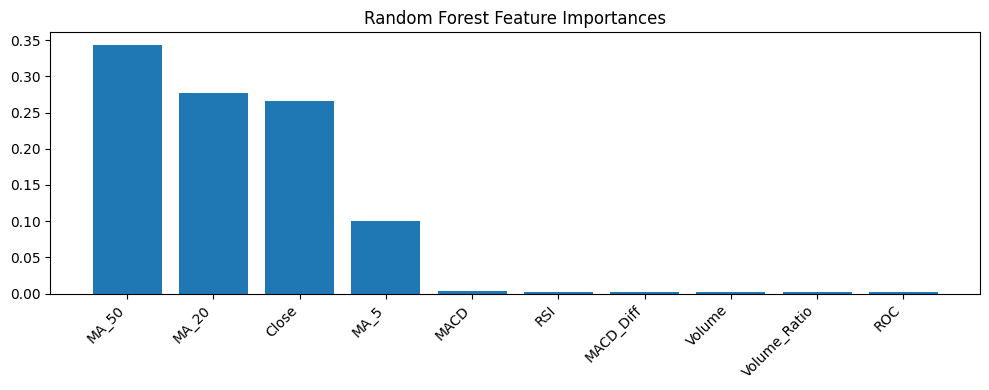

In [23]:
def feature_importance_analysis(rf_model, feature_names):
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    print('Feature Importance Ranking:')
    for i, idx in enumerate(indices):
        print(f'  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}')
    
    plt.figure(figsize=(10,4))
    plt.bar(range(len(feature_names)), importances[indices])
    plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.show()
    return importances, indices

importances, indices = feature_importance_analysis(rf_model, feature_names)

## 13. Time Series Analysis

- Decompose price into **trend** (50-day MA), **detrended** residuals, and rolling **volatility**
- **Concept:** Separating trend from noise helps distinguish structural market moves from random fluctuations

Trend: Downward  |  Slope: -0.1397/day
Current volatility: 3.2750  |  Avg: 3.1595


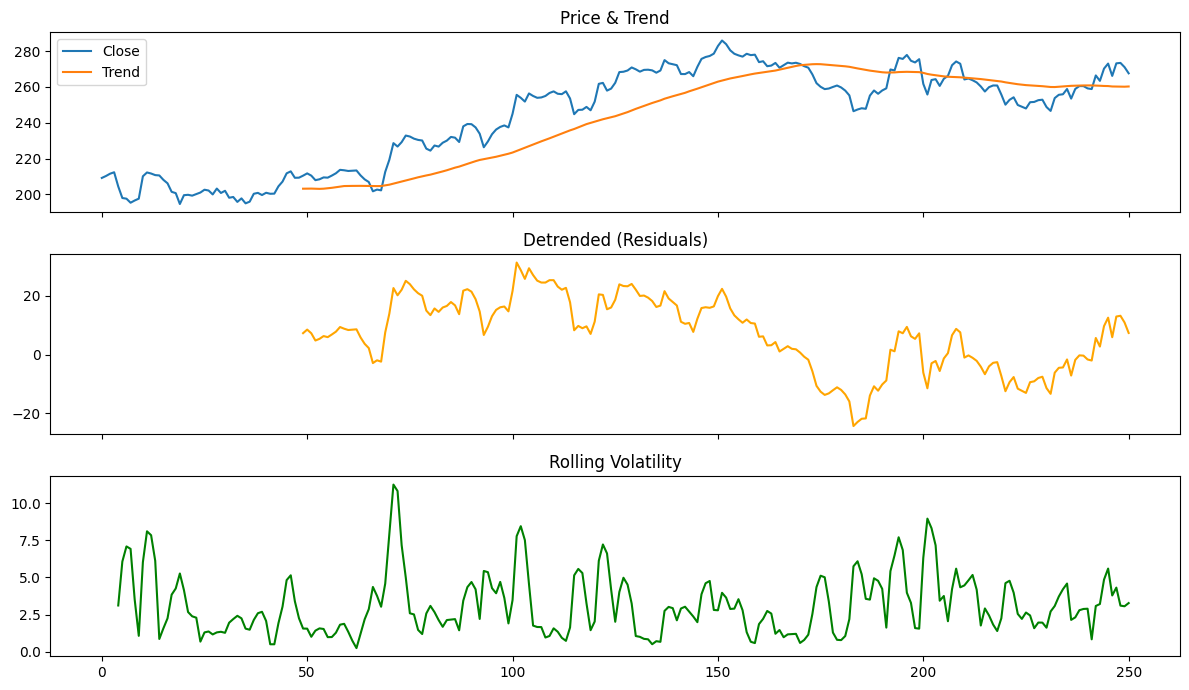

In [24]:
def time_series_decomposition(data):
    trend = data['Close'].rolling(50).mean()
    detrended = data['Close'] - trend
    seasonality = data['Close'].rolling(5).std()
    direction = 'Upward' if trend.iloc[-1] > trend.iloc[-50] else 'Downward'
    slope = (trend.iloc[-1] - trend.iloc[-50]) / 50
    print(f'Trend: {direction}  |  Slope: {slope:.4f}/day')
    print(f'Current volatility: {seasonality.iloc[-1]:.4f}  |  Avg: {seasonality.mean():.4f}')
    return trend, detrended, seasonality

trend, detrended, seasonality = time_series_decomposition(data)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(data.index, data['Close'], label='Close'); axes[0].plot(data.index, trend, label='Trend'); axes[0].legend(); axes[0].set_title('Price & Trend')
axes[1].plot(data.index, detrended, color='orange'); axes[1].set_title('Detrended (Residuals)')
axes[2].plot(data.index, seasonality, color='green'); axes[2].set_title('Rolling Volatility')
plt.tight_layout(); plt.show()

## 14. Visualization

- Six-panel chart: **price trend**, **RSI**, **return distribution**, **volume**, **predictions vs actual**, **MACD**
- **Concept:** Visualization is the bridge between raw numbers and actionable insights for both analysts and stakeholders

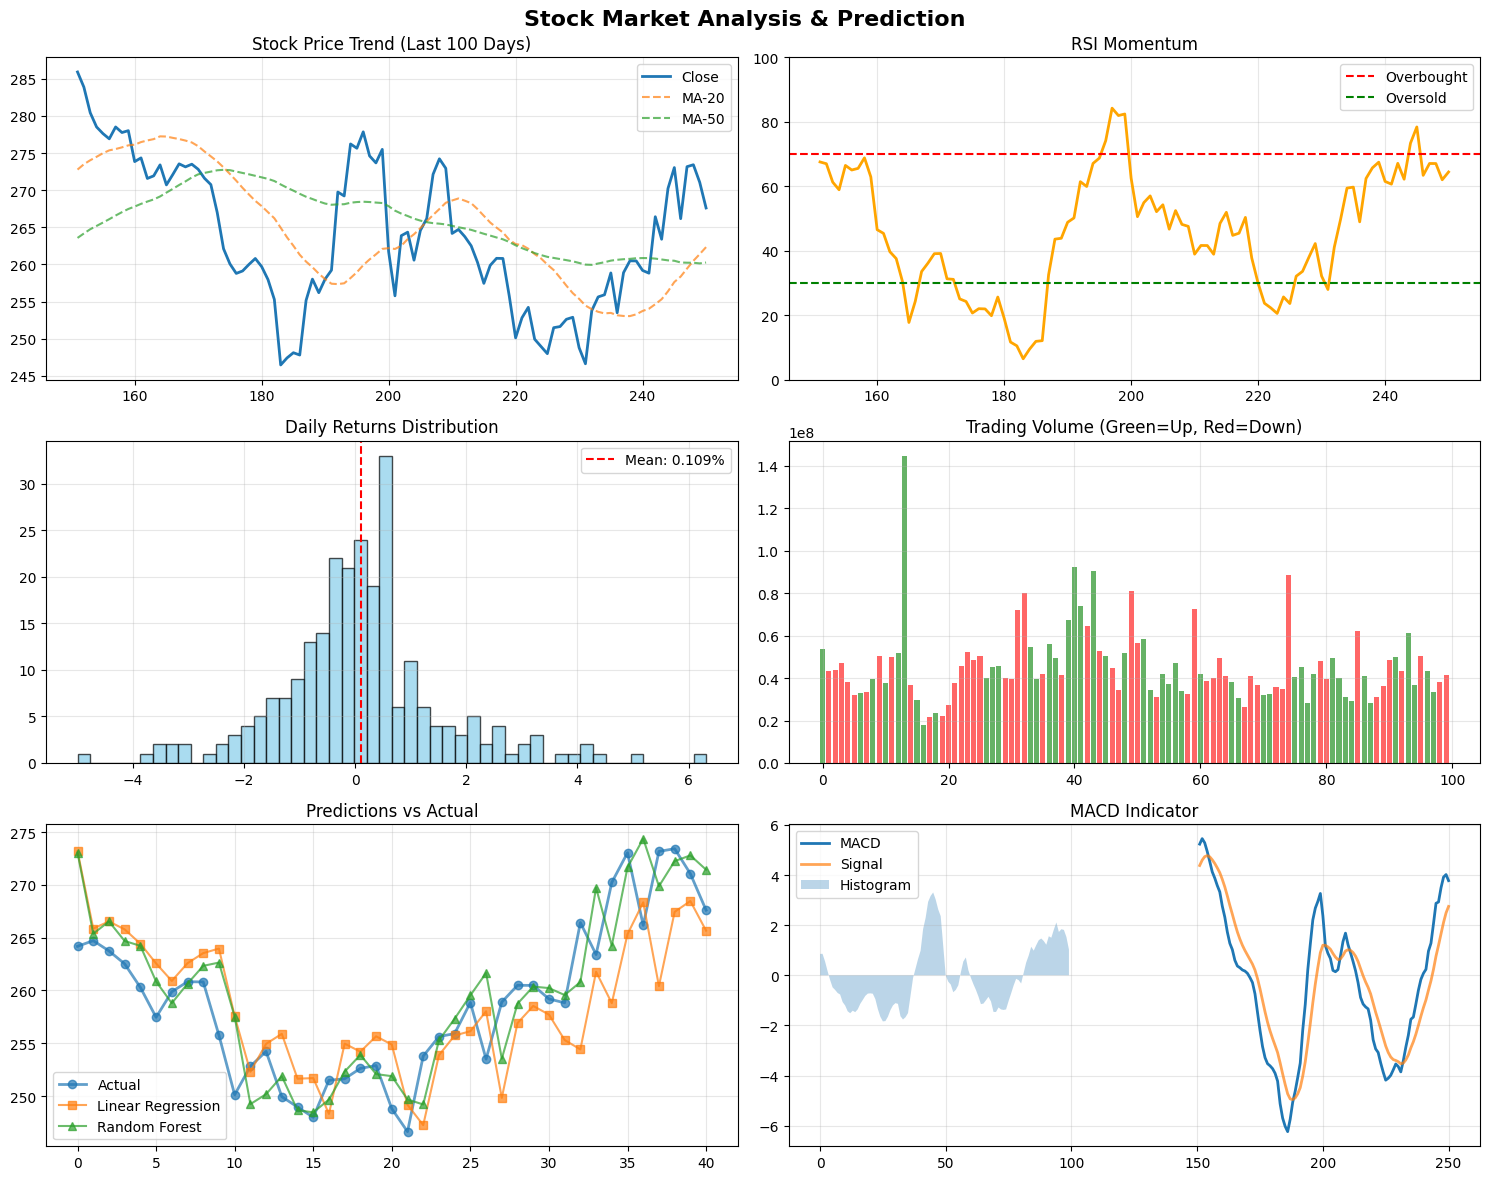

In [25]:
def plot_analysis(data, predictions, y_test):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Stock Market Analysis & Prediction', fontsize=16, fontweight='bold')

    ax1 = axes[0, 0]
    ax1.plot(data.index[-100:], data['Close'].iloc[-100:], label='Close', linewidth=2)
    ax1.plot(data.index[-100:], data['MA_20'].iloc[-100:], '--', label='MA-20', alpha=0.7)
    ax1.plot(data.index[-100:], data['MA_50'].iloc[-100:], '--', label='MA-50', alpha=0.7)
    ax1.set_title('Stock Price Trend (Last 100 Days)'); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    ax2.plot(data.index[-100:], data['RSI'].iloc[-100:], color='orange', linewidth=2)
    ax2.axhline(70, color='r', linestyle='--', label='Overbought')
    ax2.axhline(30, color='g', linestyle='--', label='Oversold')
    ax2.set_ylim([0, 100]); ax2.set_title('RSI Momentum'); ax2.legend(); ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    returns = data['Daily_Return'].dropna()
    ax3.hist(returns, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax3.axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.3f}%')
    ax3.set_title('Daily Returns Distribution'); ax3.legend(); ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    colors = ['green' if x > 0 else 'red' for x in data['Daily_Return'].iloc[-100:]]
    ax4.bar(range(len(colors)), data['Volume'].iloc[-100:], color=colors, alpha=0.6)
    ax4.set_title('Trading Volume (Green=Up, Red=Down)'); ax4.grid(True, alpha=0.3)

    ax5 = axes[2, 0]
    ax5.plot(y_test, 'o-', label='Actual', alpha=0.7, linewidth=2)
    ax5.plot(predictions['Linear Regression'], 's-', label='Linear Regression', alpha=0.7)
    ax5.plot(predictions['Random Forest'], '^-', label='Random Forest', alpha=0.7)
    ax5.set_title('Predictions vs Actual'); ax5.legend(); ax5.grid(True, alpha=0.3)

    ax6 = axes[2, 1]
    ax6.plot(data.index[-100:], data['MACD'].iloc[-100:], label='MACD', linewidth=2)
    ax6.plot(data.index[-100:], data['MACD_Signal'].iloc[-100:], label='Signal', linewidth=2, alpha=0.7)
    ax6.fill_between(range(100), data['MACD_Diff'].iloc[-100:].values, alpha=0.3, label='Histogram')
    ax6.set_title('MACD Indicator'); ax6.legend(); ax6.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

plot_analysis(data, predictions, y_test)

## 15. Summary

- Recap of all 14 concepts applied and final **model performance comparison**
- **Concept:** A structured summary communicates analytical value to stakeholders and anchors next steps

In [26]:
best_model = max(results, key=lambda x: results[x]['R2'])
best_r2 = results[best_model]['R2']

print('=' * 60)
print('PROJECT SUMMARY')
print('=' * 60)
print(f'Data Points Analyzed : {len(data)}')
print(f'Features Engineered  : {len(feature_names)}')
print(f'Models Trained       : {len(models)}')
print(f'Best Model           : {best_model}')
print(f'Best R² Score        : {best_r2:.4f}')
print()
print('KEY CONCEPTS APPLIED:')
concepts = [
    'Data Collection & Preparation', 'Data Cleaning & Preprocessing',
    'Exploratory Data Analysis (EDA)', 'Statistical Analysis',
    'Feature Engineering', 'Sentiment Analysis (NLP)',
    'Data Normalization & Scaling', 'Train-Test Split',
    'Predictive Modeling', 'Model Evaluation',
    'Feature Importance Analysis', 'Time Series Analysis',
    'Data Visualization', 'Dashboarding & Reporting'
]
for i, c in enumerate(concepts, 1):
    print(f'  {i:>2}. {c} ✓')

# Model comparison table
comparison = pd.DataFrame(results).T
print('\nModel Comparison:')
comparison

PROJECT SUMMARY
Data Points Analyzed : 251
Features Engineered  : 10
Models Trained       : 2
Best Model           : Random Forest
Best R² Score        : 0.7170

KEY CONCEPTS APPLIED:
   1. Data Collection & Preparation ✓
   2. Data Cleaning & Preprocessing ✓
   3. Exploratory Data Analysis (EDA) ✓
   4. Statistical Analysis ✓
   5. Feature Engineering ✓
   6. Sentiment Analysis (NLP) ✓
   7. Data Normalization & Scaling ✓
   8. Train-Test Split ✓
   9. Predictive Modeling ✓
  10. Model Evaluation ✓
  11. Feature Importance Analysis ✓
  12. Time Series Analysis ✓
  13. Data Visualization ✓
  14. Dashboarding & Reporting ✓

Model Comparison:


,MAE,RMSE,R2,MAPE
Linear Regression,4.226525,5.294666,0.469558,1.622657
Random Forest,2.969180,3.867606,0.716962,1.144381
